## Pré processamento de dados

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado_de_Maquina/main/Dados/iris_alterado.csv')
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
113,114,5.7,2.5,5.0,2.0,virginica
76,77,6.8,2.8,4.8,1.4,versicolor
33,34,5.5,4.2,1.4,0.2,setosa
142,143,5.8,2.7,5.1,1.9,virginica
105,106,7.6,3.0,6.6,2.1,virginica


Ao realizarmos o pré processamento de dados, realizamos uma série de processos em cima dos dados trabalhados de modo a remover erros, valores faltantes, outliers, bem como realizamos uma engenharia de atributos para entender quais atributos são relevantes mantermos/retirarmos e que novas features podemos obter dos dados que já temos inicialmente.

### Remoção de atributos irrelevantes

Com base no dataset trabalhado, percebemos que a feature `Id` é uma coluna que não é relevante para a nossa análise, visto que ela só identifica unicamente cada evento, mas não traz nenhuma informação em si sobre este.

In [137]:
# Remoção da coluna Id
df.drop(columns=['Id'], inplace=True)

In [138]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
111,6.4,2.7,5.3,1.9,virginica
91,6.1,3.0,4.6,1.4,versicolor
133,6.3,2.8,5.1,1.5,virginica
90,NaN,2.6,4.4,1.2,versicolor
33,5.5,4.2,1.4,0.2,setosa


### Análise descritiva

A partir dos dados da tabela, podemos realizar uma análise descritiva para as variáveis quantitativas contínuas.

In [139]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,143.000000,146.000000,145.000000,147.000000
mean,5.844755,3.189726,3.837241,1.271429
std,0.808466,1.682803,2.011942,1.161423
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.700000,22.700000,15.600000,11.800000


Também podemos realizar essa análise por espécie da seguinte forma

In [140]:
df['Species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [141]:
df.groupby(by='Species').describe().transpose()

Species                 setosa  versicolor  virginica
SepalLengthCm count  48.000000   47.000000  48.000000
              mean    5.022917    5.957447   6.556250
              std     0.347171    0.507228   0.618821
              min     4.300000    4.900000   4.900000
              25%     4.800000    5.600000   6.200000
              50%     5.000000    5.900000   6.450000
              75%     5.200000    6.300000   6.900000
              max     5.800000    7.000000   7.700000
SepalWidthCm  count  48.000000   49.000000  49.000000
              mean    3.418750    3.177551   2.977551
              std     0.384075    2.864602   0.324850
              min     2.300000    2.000000   2.200000
              25%     3.175000    2.500000   2.800000
              50%     3.400000    2.800000   3.000000
              75%     3.625000    3.000000   3.200000
              max     4.400000   22.700000   3.800000
PetalLengthCm count  48.000000   48.000000  49.000000
              mean    1.464583    4.262500   5.744898
              std     0.174416    0.472488   1.539489
              min     1.000000    3.000000   4.500000
              25%     1.400000    4.000000   5.100000
              50%     1.500000    4.350000   5.500000
              75%     1.525000    4.600000   5.900000
              max     1.900000    5.100000  15.600000
PetalWidthCm  count  49.000000   48.000000  50.000000
              mean    0.244898    1.325000   2.226000
              std     0.108130    0.199467   1.408257
              min     0.100000    1.000000   1.400000
              25%     0.200000    1.200000   1.800000
              50%     0.200000    1.300000   2.000000
              75%     0.300000    1.500000   2.300000
              max     0.600000    1.800000  11.800000

### Codificação de variáveis

Em alguns casos, pode ser interessante que seja feita uma recodificação de variáveis. Nem sempre isso se aplica porque em muitos casos o modelo pode entender que a codificação é um número que representa uma quantidade.

Quando temos variáveis qualitativas, geralmente transformamos em dummies (One Hot Encoding).

In [142]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['SpeciesNumerico'] = le.fit_transform(df['Species'])

In [143]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SpeciesNumerico
122,7.7,2.8,6.7,2.0,virginica,2
58,6.6,2.9,NaN,1.3,versicolor,1
8,4.4,2.9,1.4,0.2,setosa,0
62,6.0,2.2,4.0,1.0,versicolor,1
27,5.2,3.5,1.5,0.2,setosa,0


### Dados faltantes

In [144]:
df.isna().sum()

,0
SepalLengthCm,7
SepalWidthCm,4
PetalLengthCm,5
PetalWidthCm,3
Species,0
SpeciesNumerico,0


In [145]:
indices = pd.isnull(df).any().to_numpy().nonzero()
display(df.iloc[indices])

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SpeciesNumerico
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,NaN,1.5,0.2,setosa,0


Ao vermos os dados faltantes, podemos buscar a melhor estratégia a ser seguida de acordo com o conjunto de dados trabalhado.

#### Opção 1: Imputação de dados
É uma opção interessante quando o valor de poucas colunas na minha ocorrência estão incompletos e eu não desejo perder as demais. Podemos utilizar dados de medidas de posição para realizar essa imputação.

In [146]:
# Substituindo pela média dos grupos
df = df.groupby('Species').transform(lambda x: x.fillna(x.mean()))
# Poderiamos usar a mediana usando x.median(), e moda (não muito recomendada
# para variáveis quantitativas contínuas) x.mode()[0] A medida de posição que
# utilizaremos vai de acordo com o que o problema exige, mas num geral se
# recomenda a mediana por ser menos influenciada por outliers
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,SpeciesNumerico
0,5.1,3.50000,1.4,0.2,0
1,4.9,3.00000,1.4,0.2,0
2,4.7,3.20000,1.3,0.2,0
3,4.6,3.41875,1.5,0.2,0
4,5.0,3.60000,1.4,0.2,0


#### Opção 2: Remoção dos dados
A imputação de dados nem sempre é muito bem vista, então a remoção dos dados pode ser utilizada em alguns casos. Entretanto, quando uma parcela significativa do meu conjunto de dados é nula, isso gera uma grande redução das amostras, o que torna essa estratégia pouco interessante.

In [147]:
dados = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado_de_Maquina/main/Dados/iris_alterado.csv')
dados.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
89,90,5.5,2.5,4.0,1.3,versicolor
8,9,4.4,2.9,1.4,0.2,setosa
146,147,6.3,2.5,5.0,1.9,virginica
143,144,NaN,3.2,5.9,2.3,virginica
137,138,6.4,3.1,5.5,1.8,virginica


In [148]:
linhas_antes = dados.shape[0]
dados.dropna(inplace=True)
linhas_depois = dados.shape[0]

In [149]:
dados.isna().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [150]:
print(f"Antes o dataset tinha {linhas_antes} registros e passou a ter {linhas_depois}, o que representa uma perda de {(1-(linhas_depois/linhas_antes))*100}%")

Antes o dataset tinha 150 registros e passou a ter 132, o que representa uma perda de 12.0%


### Visualização dos dados

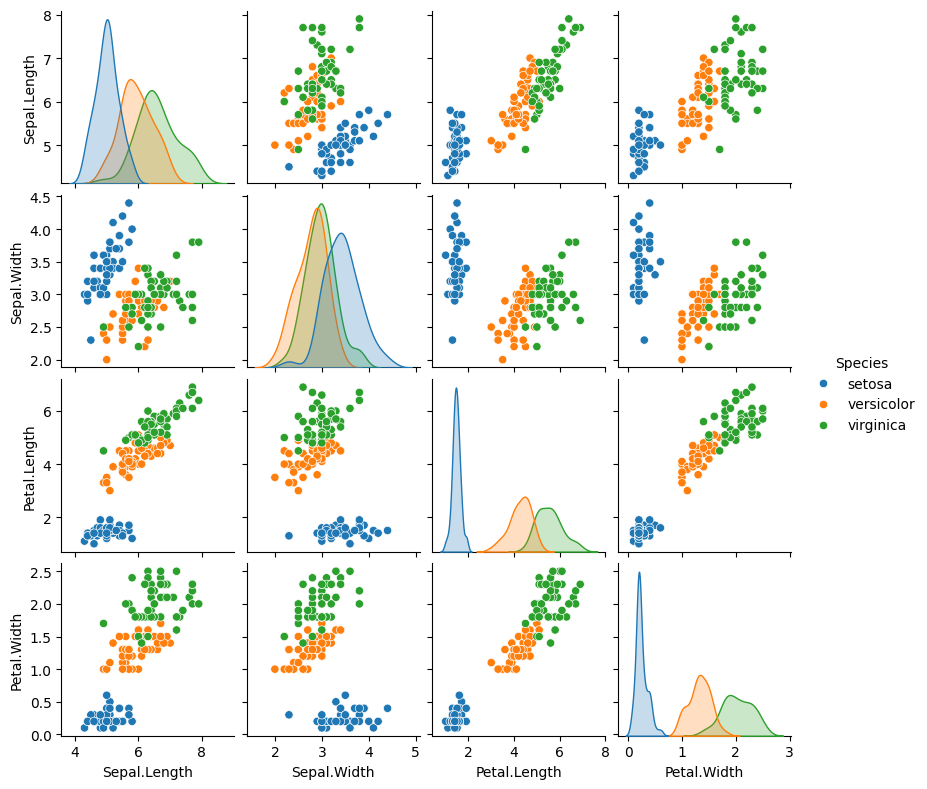

In [154]:
# Dados inalterados
df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado_de_Maquina/refs/heads/main/Dados/iris.csv')

sns.pairplot(df, hue='Species', height=2)

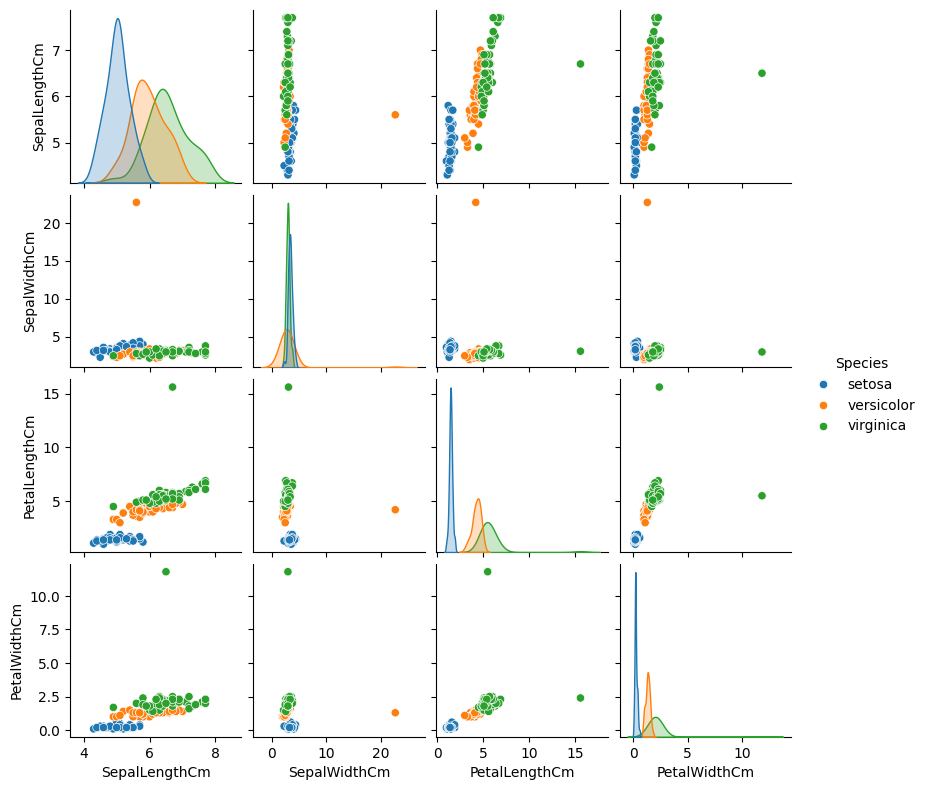

In [155]:
# Dados alterados
df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado_de_Maquina/main/Dados/iris_alterado.csv')
df.drop('Id', axis=1, inplace=True)

sns.pairplot(df, hue='Species', height=2)

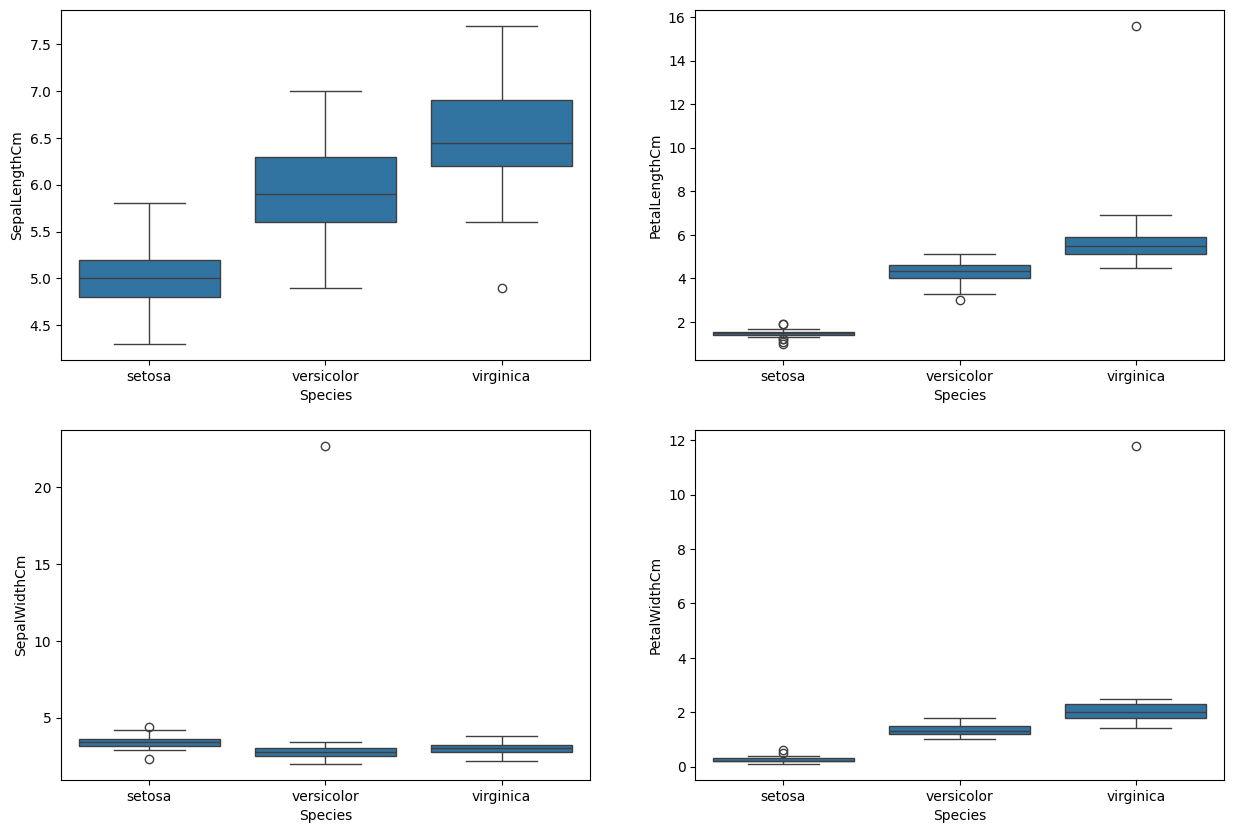

In [156]:
# Identificando outliers em dados contínuos
plt.rcParams['figure.figsize'] = (15,10)

fig, axes = plt.subplots(2,2)
sns.boxplot(data=df, y='SepalLengthCm', x='Species', ax=axes[0,0])
sns.boxplot(data=df, y='SepalWidthCm', x='Species', ax=axes[1,0])
sns.boxplot(data=df, y='PetalLengthCm', x='Species', ax=axes[0,1])
sns.boxplot(data=df, y='PetalWidthCm', x='Species', ax=axes[1,1])

plt.show()

In [170]:
# Identificando quem são os outliers
  # Classificamos no boxplot como outliers aqueles valores que ultrapassam em
  # 1.5 vezes a distância interquartil (Q3-Q1)

df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado_de_Maquina/main/Dados/iris_alterado.csv')
df = df.loc[df['Species'] == 'virginica']

data = df.iloc[:,1:5]

for atributo in data.columns:
  data = df[atributo]

  Q3, Q1 = data.quantile(0.75), data.quantile(0.25)
  IQR = Q3 - Q1

  outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))

  print(data[outliers])

106    4.9
Name: SepalLengthCm, dtype: float64
Series([], Name: SepalWidthCm, dtype: float64)
140    15.6
Name: PetalLengthCm, dtype: float64
116    11.8
Name: PetalWidthCm, dtype: float64


### One Hot Encoding

Método de codificação usado para transformar variáveis categóricas em colunas numéricas binárias, chamadas de variáveis dummy.

In [173]:
dados = pd.DataFrame({ 'Cor': ['Vermelho', 'Azul', 'Verde', 'Azul'] })
print("Dados originais:")
print(dados)

Dados originais:
        Cor
0  Vermelho
1      Azul
2     Verde
3      Azul


In [174]:
# Aplicando One-Hot Encoding
dados_ohe = pd.get_dummies(dados, columns=['Cor'])
print("\nDados após One-Hot Encoding:")
print(dados_ohe)


Dados após One-Hot Encoding:
   Cor_Azul  Cor_Verde  Cor_Vermelho
0     False      False          True
1      True      False         False
2     False       True         False
3      True      False         False


**Exercício:** Obtenha variáveis dummy (one hot encoding) para a coluna Species dos dados Iris. Compare com LabelEncoder. Quais as vantagens e desvantagens das duas estratégias?

#### Padronização dos dados

Coloca os dados em uma mesma escala, auxiliando em modelos baseados em distância.


##### Padronização Min-Max
##### StandardScaler


[59:35](https://www.youtube.com/watch?v=RxWFbzY45l0&list=PLt7qVSwRVn5b_WaicWfB_E7tzBXisBhbd&index=12)